In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
df = pd.read_csv("../data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Filas y columnas:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos por columna:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())

Filas y columnas: (891, 12)

Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Tipos de datos:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicados: 0


In [3]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop(columns=["Cabin"])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

def categoria_edad(edad):
    if edad < 12:
        return "Niño"
    elif edad < 18:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto mayor"

df["AgeCategory"] = df["Age"].apply(categoria_edad)

df[["Age", "AgeCategory", "SibSp", "Parch", "FamilySize"]].head(10)

,Age,AgeCategory,SibSp,Parch,FamilySize
0,22.0,Adulto,1,0,2
1,38.0,Adulto,1,0,2
2,26.0,Adulto,0,0,1
3,35.0,Adulto,1,0,2
4,35.0,Adulto,0,0,1
5,28.0,Adulto,0,0,1
6,54.0,Adulto,0,0,1
7,2.0,Niño,3,1,5
8,27.0,Adulto,0,2,3
9,14.0,Joven,1,0,2


In [7]:
total = len(df)
sobrevivieron = df["Survived"].sum()
porcentaje = (sobrevivieron / total) * 100

print(f"Total de pasajeros: {total}")
print(f"Sobrevivientes: {sobrevivieron}")
print(f"Porcentaje de supervivencia: {porcentaje:.2f}%")

Total de pasajeros: 891
Sobrevivientes: 342
Porcentaje de supervivencia: 38.38%


In [8]:
supervivencia_sexo = df.groupby("Sex")["Survived"].mean() * 100
print("Porcentaje de supervivencia por sexo:")
print(supervivencia_sexo.round(2))

Porcentaje de supervivencia por sexo:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [9]:
supervivencia_clase = df.groupby("Pclass")["Survived"].mean() * 100
print("Porcentaje de supervivencia por clase:")
print(supervivencia_clase.round(2))

Porcentaje de supervivencia por clase:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [10]:
supervivencia_edad = df.groupby("AgeCategory")["Survived"].mean() * 100
print("Porcentaje de supervivencia por categoría de edad:")
print(supervivencia_edad.round(2))

Porcentaje de supervivencia por categoría de edad:
AgeCategory
Adulto          36.44
Adulto mayor    26.92
Joven           48.89
Niño            57.35
Name: Survived, dtype: float64


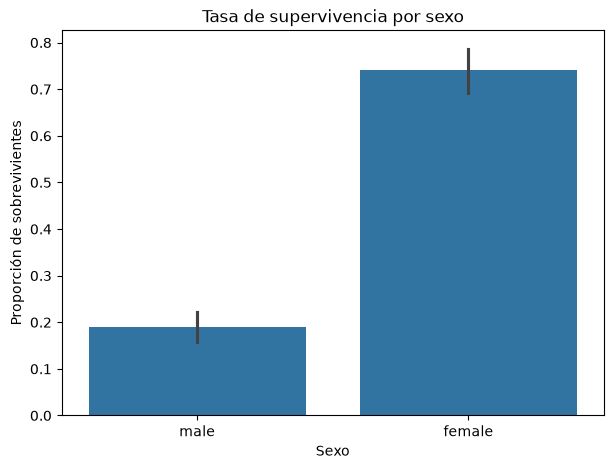

In [22]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Tasa de supervivencia por sexo")
plt.ylabel("Proporción de sobrevivientes")
plt.xlabel("Sexo")
plt.savefig("../outputs/supervivencia_sexo.png")
plt.show()

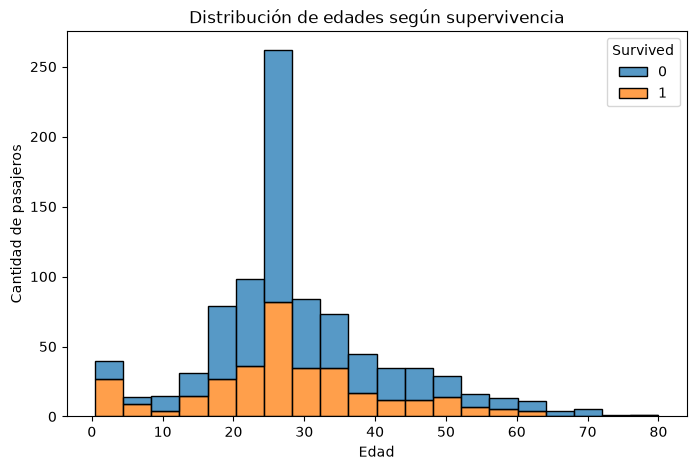

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=20)
plt.title("Distribución de edades según supervivencia")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")
plt.savefig("../outputs/distribucion_edades.png")
plt.show()

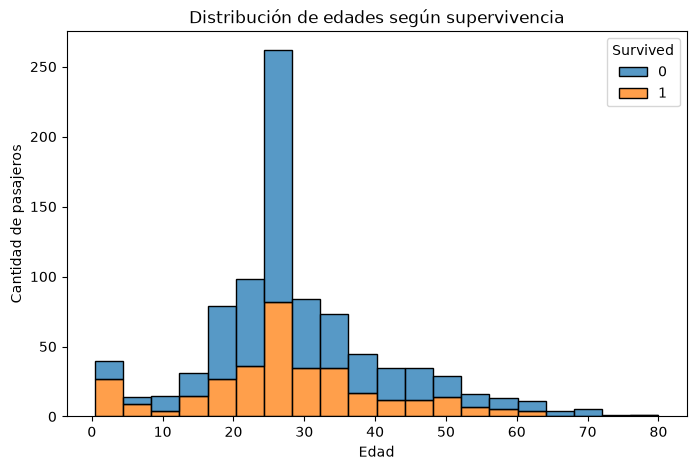

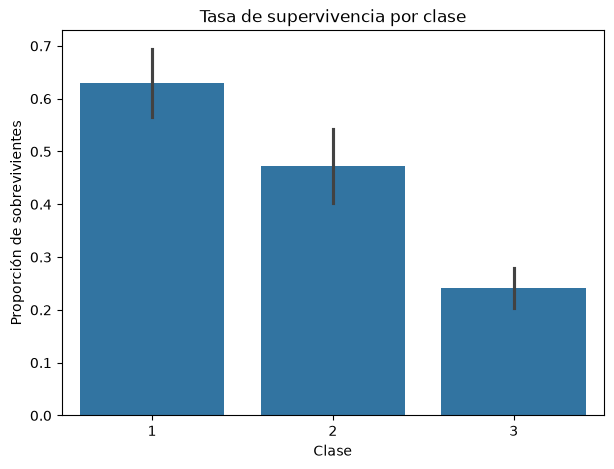

In [24]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Tasa de supervivencia por clase")
plt.ylabel("Proporción de sobrevivientes")
plt.xlabel("Clase")
plt.savefig("../outputs/supervivencia_clase.png")
plt.show()

## Conclusion

El dataset del Titanic contenia (891 pasajeros) 

1. **Supervivencia general:** solo el 38.38% de los pasajeros sobrevivió (342 de 891). La mayoría no logró salvarse en el naufragio.

2. **El sexo fue el factor más determinante:** las mujeres tuvieron una tasa de supervivencia del 74.20%, casi cuatro veces mayor que la de los hombres (18.89%). ahi podria decir que era porque antes se decia las "mujeres y niños primero" al momento de abordar los botes salvavidas.

3. **La clase socioeconómica influyó fuertemente:** los pasajeros de primera clase sobrevivieron en un 62.96%, los de segunda en un 47.28% y los de tercera solo en un 24.24%. 

4. **Los niños tuvieron ventaja:** la categoría "Niño" (menores de 12 años) alcanzó un 57.35% de supervivencia, seguida por "Joven" (48.89%), "Adulto" (36.44%) y "Adulto mayor" (26.92%). Esto quiere decir que le daban prioridad a los menores durante la evacuación.

5. **Tratamiento de datos faltantes:** la columna `Age` presentaba 177 valores nulos que se rellenaron con la mediana; `Embarked` tenía 2 nulos rellenados con la moda; y `Cabin` fue eliminada al tener 687 nulos (77% de los datos), lo que la volvía poco confiable.

6. **Variables creadas:** se generó `FamilySize` y `AgeCategory` para clasificar a los pasajeros en Niño, Joven, Adulto y Adulto mayor.

Entonces podemos ver que para sobrevivir al hundimiento del Titanic tomaban en cuenta cosas como el sexo, la clase socioeconómica y la edad, en ese orden de importancia.